In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
# Read data
data = pd.read_csv('2023-05-12.csv')

# Rename columns
data = data.rename(columns=str.lower)
print(data.columns)

# Keep only station_code == 129 (Pink Mountain) & 131 (Muskwa) & 120 (Silver)
data = data[data['station_code'].isin([129, 131, 120])]

# Convert date_time column to datetime type
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y%m%d%H')

# Keep only date_time and temperature columns
data = data[['date_time', 'station_code', 'temperature']]

Index(['station_code', 'date_time', 'precipitation', 'temperature',
       'relative_humidity', 'wind_speed', 'wind_direction',
       'fine_fuel_moisture_code', 'initial_spread_index', 'fire_weather_index',
       'duff_moisture_code', 'drought_code', 'buildup_index', 'danger_rating',
       'rn_1_pluvio1', 'snow_depth', 'snow_depth_quality',
       'precip_pluvio1_status', 'precip_pluvio1_total', 'rn_1_pluvio2',
       'precip_pluvio2_status', 'precip_pluvio2_total', 'rn_1_rit',
       'precip_rit_status', 'precip_rit_total', 'precip_rgt',
       'solar_radiation_licor', 'solar_radiation_cm3'],
      dtype='object')


In [52]:
data

,date_time,station_code,temperature
504,2023-05-12 00:00:00,120,8.5
505,2023-05-12 01:00:00,120,7.6
506,2023-05-12 02:00:00,120,4.2
507,2023-05-12 03:00:00,120,5.3
508,2023-05-12 04:00:00,120,3.0
...,...,...,...
643,2023-05-12 19:00:00,131,20.5
644,2023-05-12 20:00:00,131,19.4
645,2023-05-12 21:00:00,131,18.7
646,2023-05-12 22:00:00,131,18.5


In [45]:
# Prepare data for verif
data_verif = data.copy()

data_verif['date'] = data_verif['date_time'].dt.strftime('%Y%m%d')
data_verif['hour'] = data_verif['date_time'].dt.hour
data_verif['leadtime'] = 0

# print(data_verif['date'].head())
# print(data_verif['hour'].head())
# print(data_verif['leadtime'].head())

In [46]:
data_verif

,station_code,date_time,precipitation,temperature,relative_humidity,wind_speed,wind_direction,fine_fuel_moisture_code,initial_spread_index,fire_weather_index,...,precip_pluvio2_total,rn_1_rit,precip_rit_status,precip_rit_total,precip_rgt,solar_radiation_licor,solar_radiation_cm3,date,hour,leadtime
600,129,2023-05-12 00:00:00,0.0,-1.4,89.0,1.8,297.0,89.176,4.171,10.847,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,0,0
601,129,2023-05-12 01:00:00,0.0,-2.3,92.0,5.0,286.0,88.240,4.285,11.089,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,1,0
602,129,2023-05-12 02:00:00,0.0,-2.7,92.0,4.1,1.0,87.409,3.635,9.675,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,2,0
603,129,2023-05-12 03:00:00,0.0,-2.9,91.0,2.0,16.0,86.737,2.972,8.134,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,3,0
604,129,2023-05-12 04:00:00,0.0,-3.0,93.0,3.8,1.0,85.993,2.930,8.032,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,4,0
605,129,2023-05-12 05:00:00,0.0,-2.2,91.0,4.0,268.0,85.361,2.710,7.492,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,5,0
606,129,2023-05-12 06:00:00,0.0,3.6,71.0,1.9,8.0,85.219,2.390,6.679,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,6,0
607,129,2023-05-12 07:00:00,0.0,13.5,40.0,1.6,229.0,85.512,2.452,6.840,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,7,0
608,129,2023-05-12 08:00:00,0.0,16.7,34.0,4.4,354.0,86.036,3.038,8.293,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,8,0
609,129,2023-05-12 09:00:00,0.0,19.1,29.0,13.7,198.0,86.854,5.449,13.438,...,0.0,NaN,0.0,0.0,NaN,0.0,NaN,20230512,9,0


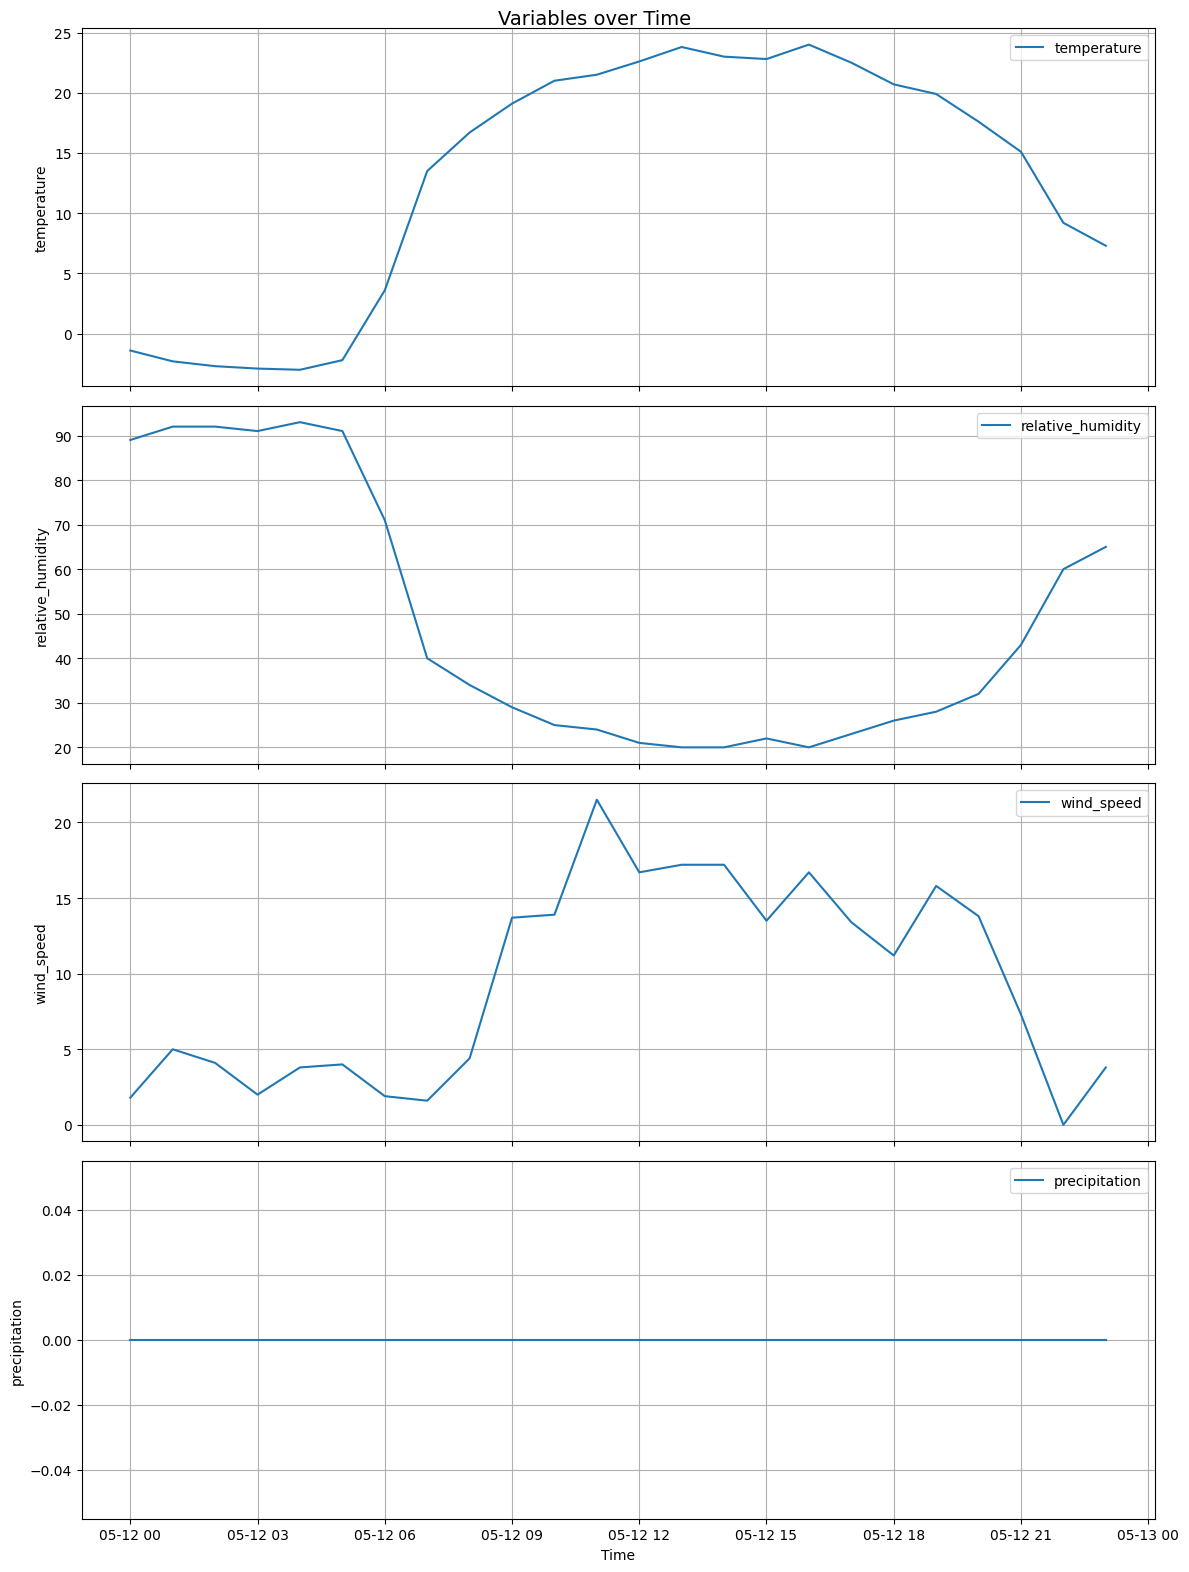

In [38]:
# Plotting
# Select variables to plot
# vars = [col for col in data.columns if col not in ['date_time', 'station_code']]
vars = ['temperature', 'relative_humidity', 'wind_speed', 'precipitation']
fig, axes = plt.subplots(nrows=len(vars), ncols=1, figsize=(12, 4 * len(vars)), sharex=True)
for ax, var in zip(axes, vars):
    ax.plot(data['date_time'], data[var], label=var)
    ax.set_ylabel(var)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Time')
plt.suptitle('Variables over Time', fontsize=14)
plt.tight_layout()
plt.show()